In [1]:
import pathlib

import itertools
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import pickle
import pingouin as pg


import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u
from STX3KO_analyses.run_sig_fields_spatial_perm import filter_fields


ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice


plt.rcParams['pdf.fonttype']=42
plt.rcParams['font.family'] ='sans-serif'
plt.rcParams['font.serif'] = 'Arial'


%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
figdir = pathlib.Path('/mnt/BigDisk/fig_scratch/stx3/fig3_place_fields')
figdir.mkdir(exist_ok=True, parents=True)

In [3]:
with open('/home/mplitt/shuffle_pkls/dense_place_field_spatial_shuffle_F_dff.pkl','rb') as file:
    shuff_results = pickle.load(file)
            

# number of fields per cell 

In [4]:
df = {'cre': [], 'mouse': [], 'day': [], 'nov': [], 'n_fields': []}
for key, mice in zip(('ctrl', 'ko'),(ctrl_mice, ko_mice)):
    for mouse in mice:
        for day in range(6):
            for nov in ( 'fam', 'nov'):

                rising_edges = shuff_results[mouse][day][nov]['rising_edges']
                falling_edges = shuff_results[mouse][day][nov]['falling_edges']

                width = falling_edges[:,1]-rising_edges[:,1]
                mask = (width>1) * (width<25) 
                n_fields = np.bincount(rising_edges[mask,0])
                

                # widths = shuff_resu
        
                n_fields = n_fields[n_fields>0]

                for n in n_fields:
                    df['cre'].append(key)
                    df['mouse'].append(mouse)
                    df['day'].append(day)
                    df['nov'].append(nov)
                    df['n_fields'].append(n)

df = pd.DataFrame.from_dict(df)

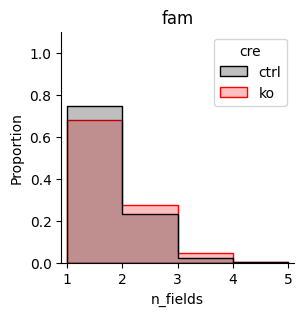

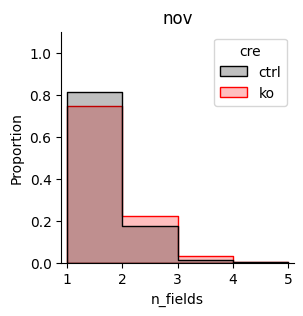

In [5]:
for nov in ('fam', 'nov'):

    fig,ax = plt.subplots(figsize=[3,3])
    sns.histplot(data=df.loc[df['nov']==nov], x='n_fields', hue='cre', cumulative=False, hue_order=('ctrl', 'ko'), palette=['black', 'red'],
                binwidth=1, fill=True, element = 'step', stat='proportion', common_norm=False, ax=ax)
    ax.set_ylim([0,1.1])
    ax.set_xlim([.9,5.1])

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title(nov)

    fig.savefig(figdir / f'fields_per_cell_hist_{nov}.pdf', bbox_inches='tight')


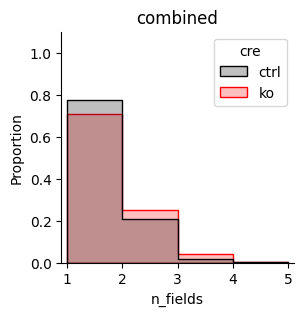

In [6]:


fig,ax = plt.subplots(figsize=[3,3])
sns.histplot(data=df, x='n_fields', hue='cre', cumulative=False, hue_order=('ctrl', 'ko'), palette=['black', 'red'],
            binwidth=1, fill=True, element = 'step', stat='proportion', common_norm=False, ax=ax)
ax.set_ylim([0,1.1])
ax.set_xlim([.9,5.1])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title('combined')

fig.savefig(figdir / f'fields_per_cell_hist_combined.pdf', bbox_inches='tight')

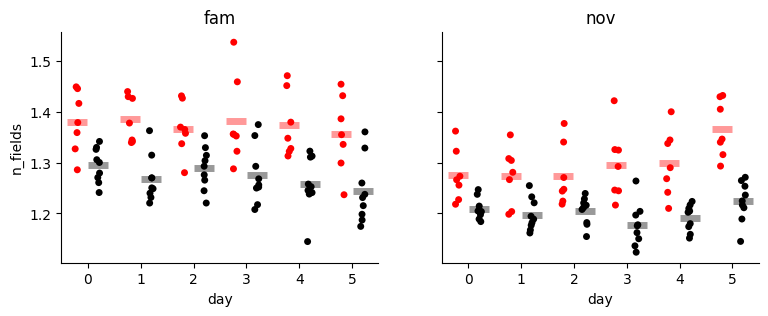

In [7]:
df_mu = df.groupby(['mouse','day','cre','nov'])['n_fields'].mean().reset_index()
df_mu.head()
fig,ax = plt.subplots(1,2, figsize=[9,3], sharey = True)
for i, nov in enumerate(('fam','nov')):
    sns.stripplot(data=df_mu.loc[df_mu['nov']==nov,:],
                x='day',
                y='n_fields',
                hue='cre', 
                hue_order=('ko', 'ctrl'), 
                palette=['red', 'black'],
                dodge=True,
                ax=ax[i],
                legend=False)
    


    sns.pointplot(data=df_mu.loc[df_mu['nov']==nov,:],
              x='day',
              y='n_fields',
              errorbar=None,
              hue='cre',
              hue_order = ['ko', 'ctrl'],
              dodge = .4,
              palette = ['red','black'],
              ax=ax[i],
              linestyles="none",
              marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,
              )
    ax[i].set_title(nov)

for a in ax.flatten():
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)

fig.savefig( figdir / 'num_fields_per_day.pdf', bbox_inches='tight')


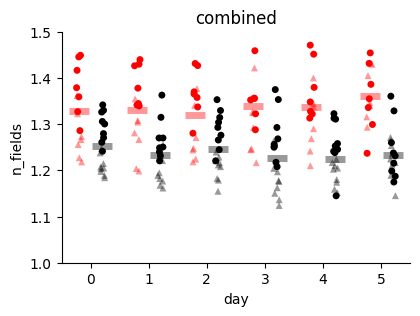

In [8]:
df_mu = df.groupby(['mouse','day','cre','nov'])['n_fields'].mean().reset_index()
df_mu.head()
fig,ax = plt.subplots(figsize=[4.5,3], sharey = True)
sns.stripplot(data=df_mu.loc[df_mu['nov']=='fam',:],
            x='day',
            y='n_fields',
            hue='cre', 
            hue_order=('ko', 'ctrl'), 
            palette=['red', 'black'],
            dodge=True,
            ax=ax,
            legend=False)

sns.stripplot(data=df_mu.loc[df_mu['nov']=='nov',:],
            x='day',
            y='n_fields',
            hue='cre', 
            hue_order=('ko', 'ctrl'), 
            palette=['red', 'black'],
            marker='^',
            alpha=.4,
            dodge=True,
            ax=ax,
            legend=False)



sns.pointplot(data=df_mu,
            x='day',
            y='n_fields',
            errorbar=None,
            hue='cre',
            hue_order = ['ko', 'ctrl'],
            dodge = .4,
            palette = ['red','black'],
            ax=ax,
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,
            )
ax.set_title('combined')
ax.set_ylim([1,1.5])


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig( figdir / 'num_fields_per_day_combined.pdf', bbox_inches='tight')


In [9]:
with open('/home/mplitt/shuffle_pkls/dense_n_fields_mixedlm_shuffle.pkl', 'rb') as file:
        model_shuff_results = pickle.load(file)

for stat in model_shuff_results.keys():

    true_coef = model_shuff_results[stat]['genotype coef.']
    shuff_coefs = model_shuff_results[stat]['shuffle genotype coef.']
    p = (true_coef<shuff_coefs).sum()/float(shuff_coefs.shape[0])
    print(f"{stat} true coef = {true_coef}, p = {p} ")



n_fields true coef = 0.0811189396003333, p = 0.003321678321678322 
rank_n_fields true coef = 3989.0634357832523, p = 0.0034965034965034965 


# field width 

In [10]:
df = {'cre': [], 'mouse': [], 'day': [], 'nov': [], 'width': []}
for key, mice in zip(('ctrl', 'ko'),(ctrl_mice, ko_mice)):
    for mouse in mice:
        for day in range(6):
            for nov in ('fam','nov'):
                rising_edges = shuff_results[mouse][day][nov]['rising_edges']
                falling_edges = shuff_results[mouse][day][nov]['falling_edges']
                widths = shuff_results[mouse][day][nov]['field_widths']
                
                mask = (widths>1) * (widths<25) * (rising_edges[:,1]>0) * (falling_edges[:,1]<29)
                widths = widths[mask]
                

                for w in widths:
                    df['cre'].append(key)
                    df['mouse'].append(mouse)
                    df['day'].append(day)
                    df['nov'].append(nov)
             
                    df['width'].append(w*10)
df = pd.DataFrame(df)

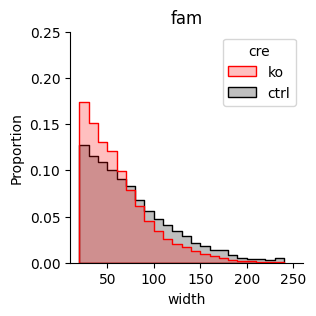

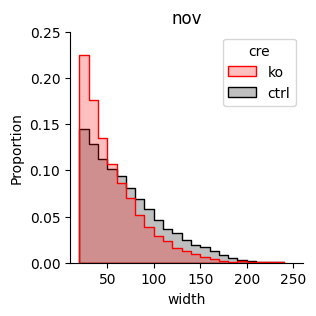

In [11]:
for nov in ('fam', 'nov'):
    fig,ax = plt.subplots(figsize=[3,3])
    sns.histplot(data=df.loc[df['nov']==nov,:], 
                x='width', 
                hue='cre', 
                cumulative=False, 
                hue_order=('ko', 'ctrl'), 
                palette=['red', 'black'],
                binwidth=10, 
                fill=True, element = 'step', stat='proportion', common_norm=False, ax=ax)
    # ax.set_ylim([0,1.1])
    ax.set_xlim([10,260])
    ax.set_ylim([0,.25])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title(nov)
    fig.savefig(figdir / f'field_widths_hist_{nov}.pdf', bbox_inches='tight')


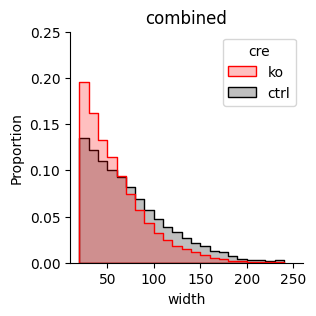

In [12]:

fig,ax = plt.subplots(figsize=[3,3])
sns.histplot(data=df, 
            x='width', 
            hue='cre', 
            cumulative=False, 
            hue_order=('ko', 'ctrl'), 
            palette=['red', 'black'],
            binwidth=10, 
            fill=True, element = 'step', stat='proportion', common_norm=False, ax=ax)
# ax.set_ylim([0,1.1])
ax.set_xlim([10,260])
ax.set_ylim([0,.25])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title('combined')
fig.savefig(figdir / f'field_widths_hist_combined.pdf', bbox_inches='tight')


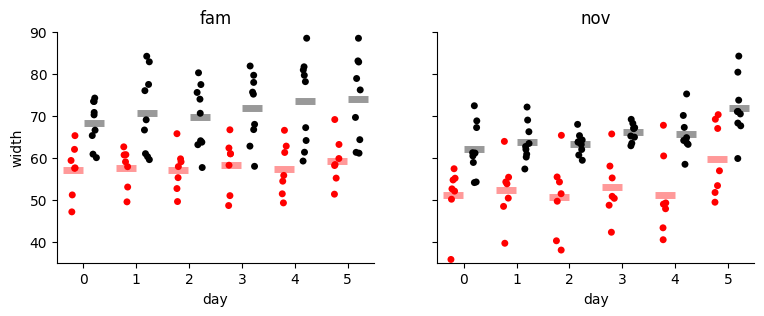

In [13]:
df_mu = df.groupby(['mouse','day','cre','nov'])['width'].mean().reset_index()
df_mu.head()
fig,ax = plt.subplots(1,2, figsize=[9,3], sharey=True)
for i, nov in enumerate(('fam','nov')):
    ax[i] = sns.stripplot(data=df_mu.loc[df_mu['nov']==nov,:],
                x='day',
                y='width',
                hue='cre', 
                hue_order=('ko', 'ctrl'), 
                palette=['red', 'black'],
                dodge=True,
                ax=ax[i],
                legend=False)
    
    sns.pointplot(data=df_mu.loc[df_mu['nov']==nov,:],
              x='day',
              y='width',
              errorbar=None,
              hue='cre',
              hue_order = ['ko', 'ctrl'],
              dodge = .4,
              palette = ['red','black'],
              ax=ax[i],
              linestyles="none",
              marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,
              )
    ax[i].set_title(nov)
    ax[i].set_ylim([35,90])
for a in ax.flatten():
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)

fig.savefig( figdir / 'field_widths_per_day.pdf', bbox_inches='tight')

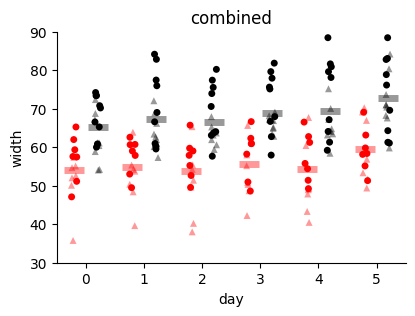

In [17]:
df_mu = df.groupby(['mouse','day','cre','nov'])['width'].mean().reset_index()
df_mu.head()
fig,ax = plt.subplots(figsize=[4.5,3], sharey=True)

sns.stripplot(data=df_mu.loc[df_mu['nov']=='fam',:],
            x='day',
            y='width',
            hue='cre', 
            hue_order=('ko', 'ctrl'), 
            palette=['red', 'black'],
            dodge=True,
            ax=ax,
            legend=False)

sns.stripplot(data=df_mu.loc[df_mu['nov']=='nov',:],
            x='day',
            y='width',
            hue='cre', 
            hue_order=('ko', 'ctrl'), 
            palette=['red', 'black'],
            marker='^',
            alpha=.4,
            dodge=True,
            ax=ax,
            legend=False)


sns.pointplot(data=df_mu,
            x='day',
            y='width',
            errorbar=None,
            hue='cre',
            hue_order = ['ko', 'ctrl'],
            dodge = .4,
            palette = ['red','black'],
            ax=ax,
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,
            )
ax.set_title('combined')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim([30,90])

fig.savefig( figdir / 'field_widths_per_day_combined.pdf', bbox_inches='tight')

In [18]:
with open('/home/mplitt/shuffle_pkls/dense_width_mixedlm_shuffle.pkl', 'rb') as file:
        model_shuff_results = pickle.load(file)

for stat in model_shuff_results.keys():

    true_coef = model_shuff_results[stat]['genotype coef.']
    shuff_coefs = model_shuff_results[stat]['shuffle genotype coef.']
    p = (true_coef>shuff_coefs).sum()/float(shuff_coefs.shape[0])
    print(f"{stat} true coef = {true_coef}, p = {p} ")



width true coef = -11.260519336395545, p = 0.001486013986013986 
rank_width true coef = -7707.646501764529, p = 0.0006993006993006993 
